In [1]:
import os
# Silence joblib LOKY warning about physical CPU cores
os.environ['LOKY_MAX_CPU_COUNT'] = '8'  # adjust to your CPU count
# Avoid KMeans memory leak on Windows with MKL
os.environ['OMP_NUM_THREADS'] = '1'

### 1. What are some of the main applications of clustering algorithms?

- **Customer Segmentation** - cluster customers based on purchases or activity on a website
- **Data Analysis** - divide up a new dataset based on underlying groups
- **Dimensionality Reduction** - generate affinity measures and replace feature set with a lower dimensionality affinity clusters
- **Feature Engineering** - as we did in chapter 2 adding geographic cluster affinity features
- **Anomaly or fraud or outlier detection** - an instance with low affinity to all clusters may represent an anomaly
- **Semi-supervised learning** - if you have a few labels, perform clustering and apply labels to all instances of the cluster
- **Search Engines** - find images similar to reference images (similar to above)
- **Image segmentation** - a dimensionality reduction technique

### 2. Describe two techniques to select the right number of clusters when using k-means.

**1. Elbow Method**
- Plot inertia as a function of the number of clusters k
- Look for the "elbow" point where adding more clusters produces diminishing returns

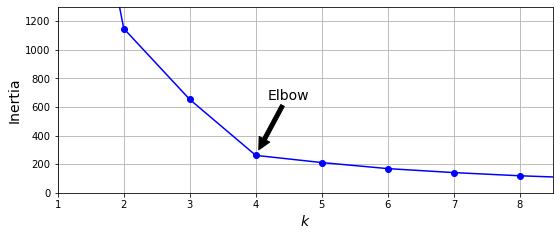

**2. Silhouette Score**
- Compute silhouette score for different values of k and choose the k with the highest average score
- Provides a more objective measure than visual inspection of the elbow

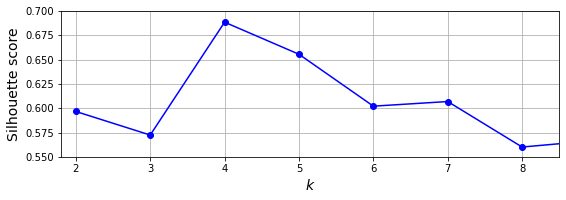

- Further discussion covers the silhouette diagram; A diagram for each k, with each diagram containing one knife shape per cluster, its width represents the sorted silhouette coefficients of the instances, and the shapes height indicated the number of instances of the cluster.
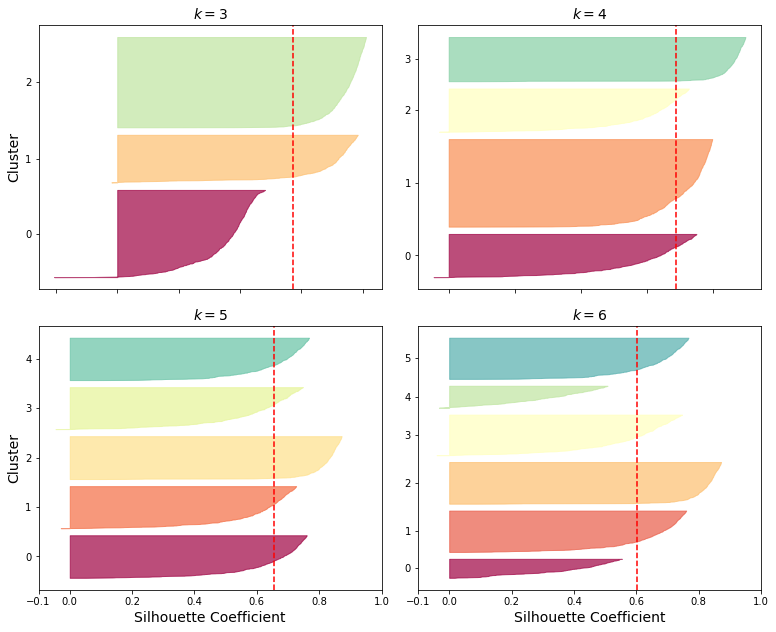

### 3. What is label propagation? Why would you implement it, and how?

**What it is:**
- Label propagation is a semi-supervised learning technique that spreads labels from a small labeled dataset to unlabeled instances
- It leverages the structure of the data (similarity/proximity) to infer labels for unlabeled points
- Assumes that nearby points or connected points in a similarity graph are likely to share the same label

**Why implement it:**
- When you have a large dataset but only a few labeled examples (labeling is expensive/time-consuming)
- To extend a small labeled dataset without manual annotation
- When unlabeled data provides useful structural information about class boundaries
- Semi-supervised learning can achieve better performance than supervised learning on small labeled sets alone

**How it works:**
1. Build a similarity graph connecting instances based on distance or k-nearest neighbors
2. Assign known labels to labeled instances
3. Iteratively propagate labels through the graph:
   - Each unlabeled node takes on a weighted average of its neighbors' labels
   - Labels diffuse through connected regions
4. Repeat until convergence or a fixed number of iterations
5. Assign final labels based on the strongest label at each node

**In scikit-learn:** Use `LabelPropagation` or `LabelSpreading` classes with partially labeled data (unlabeled points marked as -1).

### 4. Load the MNIST dataset and split it into training and test sets

In [2]:
from sklearn.datasets import fetch_openml
import numpy as np

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist["data"], mnist["target"]

# Split into training (first 60,000) and test (remaining 10,000) sets
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

# Cast dtypes for performance and consistency
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

### ...Train a random forest classifier, time it, and evaluate on the test set

In [3]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Ensure types are correct if re-running independently
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

clf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

start = time.time()
clf.fit(X_train, y_train)
elapsed = time.time() - start

start_pred = time.time()
y_pred = clf.predict(X_test)
pred_elapsed = time.time() - start_pred

acc = accuracy_score(y_test, y_pred)
print(f"Training time: {elapsed:.2f} s")
print(f"Prediction time: {pred_elapsed:.2f} s")
print(f"Test accuracy: {acc:.4f}")

Training time: 8.85 s
Prediction time: 0.09 s
Test accuracy: 0.9707


### ...Reduce dimensionality with PCA (95% explained variance)

In [4]:
from sklearn.decomposition import PCA
import numpy as np

# Fit PCA to retain 95% of the variance
pca_95 = PCA(n_components=0.95, svd_solver='full')
X_train_pca = pca_95.fit_transform(X_train)
X_test_pca = pca_95.transform(X_test)

explained_var = pca_95.explained_variance_ratio_.sum()
print(f"Original shape: {X_train.shape} -> Reduced shape: {X_train_pca.shape}")
print(f"Explained variance retained: {explained_var:.4f}")

Original shape: (60000, 784) -> Reduced shape: (60000, 154)
Explained variance retained: 0.9502


In [5]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Ensure PCA inputs are correct types
X_train_pca = X_train_pca.astype(np.float32)
X_test_pca = X_test_pca.astype(np.float32)
y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

clf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

start = time.time()
clf.fit(X_train_pca, y_train)
elapsed = time.time() - start

start_pred = time.time()
y_pred_pca = clf.predict(X_test_pca)
pred_elapsed = time.time() - start_pred

acc_pca = accuracy_score(y_test, y_pred_pca)
print(f"Training time: {elapsed:.2f} s")
print(f"Prediction time: {pred_elapsed:.2f} s")
print(f"Test accuracy: {acc_pca:.4f}")

Training time: 33.36 s
Prediction time: 0.07 s
Test accuracy: 0.9504


## After dimension reduction via PCA
### Train Time increased 3x - from 8.85 seconds to 33.36 seconds

### Accuracy declined 2 percentage points - from 97.07% to 95.04%

### Repeat with SGDClassifier (original and PCA)

### ===========================================
## Repeat with GDCClassifier

In [6]:
import time
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# Ensure numeric types
X_train_sgd = X_train.astype(np.float32)
X_test_sgd = X_test.astype(np.float32)
y_train_sgd = y_train.astype(np.int64)
y_test_sgd = y_test.astype(np.int64)

sgd = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    max_iter=500,
    tol=1e-3,
    random_state=42,
    n_jobs=-1,
)

start = time.time()
sgd.fit(X_train_sgd, y_train_sgd)
elapsed_sgd = time.time() - start

start_pred = time.time()
y_pred_sgd = sgd.predict(X_test_sgd)
pred_elapsed_sgd = time.time() - start_pred

acc_sgd = accuracy_score(y_test_sgd, y_pred_sgd)
print(f"SGD (original) - Training time: {elapsed_sgd:.2f} s")
print(f"SGD (original) - Prediction time: {pred_elapsed_sgd:.2f} s")
print(f"SGD (original) - Test accuracy: {acc_sgd:.4f}")

SGD (original) - Training time: 22.71 s
SGD (original) - Prediction time: 0.04 s
SGD (original) - Test accuracy: 0.8686


In [7]:
import numpy as np
import time
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# Ensure PCA features and labels are correct types
X_train_pca_sgd = X_train_pca.astype(np.float32)
X_test_pca_sgd = X_test_pca.astype(np.float32)
y_train_sgd = y_train.astype(np.int64)
y_test_sgd = y_test.astype(np.int64)

sgd_pca = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    max_iter=500,
    tol=1e-3,
    random_state=42,
    n_jobs=-1,
)

start = time.time()
sgd_pca.fit(X_train_pca_sgd, y_train_sgd)
elapsed_sgd_pca = time.time() - start

start_pred = time.time()
y_pred_sgd_pca = sgd_pca.predict(X_test_pca_sgd)
pred_elapsed_sgd_pca = time.time() - start_pred

acc_sgd_pca = accuracy_score(y_test_sgd, y_pred_sgd_pca)
print(f"SGD (PCA) - Training time: {elapsed_sgd_pca:.2f} s")
print(f"SGD (PCA) - Prediction time: {pred_elapsed_sgd_pca:.2f} s")
print(f"SGD (PCA) - Test accuracy: {acc_sgd_pca:.4f}")

SGD (PCA) - Training time: 5.90 s
SGD (PCA) - Prediction time: 0.00 s
SGD (PCA) - Test accuracy: 0.8927


## After dimension reduction via PCA using the SGDClassifier
### Train Time decreased (from a higher initial level) - from 22.71 seconds to 5.90 seconds

### Accuracy increased a bit (from lower levels) - from 86.86% to 89.27%

# 5. Olivetti Faces Dataset

In [8]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np

# Load Olivetti Faces dataset
faces = fetch_olivetti_faces()
X = faces.data.astype(np.float32)
y = faces.target.astype(np.int64)
images = faces.images

print(f"Data shape: {X.shape}")
print(f"Images shape: {images.shape}")
print(f"Target shape: {y.shape}")

Data shape: (400, 4096)
Images shape: (400, 64, 64)
Target shape: (400,)


### Split into train, validation, and test sets with stratification
Since we have 40 people with 10 images each, we'll use stratified sampling to ensure each person is equally represented in each set.

In [9]:
from sklearn.model_selection import train_test_split

# First split: separate out test set (20% of data)
X_temp_faces, X_test_faces, y_temp_faces, y_test_faces = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Second split: separate remaining into train and validation (75/25 of remaining = 60/20 overall)
X_train_faces, X_val_faces, y_train_faces, y_val_faces = train_test_split(
    X_temp_faces, y_temp_faces, test_size=0.25, stratify=y_temp_faces, random_state=42
)

print(f"Training set: {X_train_faces.shape[0]} images")
print(f"Validation set: {X_val_faces.shape[0]} images")
print(f"Test set: {X_test_faces.shape[0]} images")
print(f"\nPeople in training set: {len(np.unique(y_train_faces))}")
print(f"People in validation set: {len(np.unique(y_val_faces))}")
print(f"People in test set: {len(np.unique(y_test_faces))}")

Training set: 240 images
Validation set: 80 images
Test set: 80 images

People in training set: 40
People in validation set: 40
People in test set: 40


### Find optimal number of clusters using Elbow Method and Silhouette Score

k=70: inertia=4399.09, silhouette=0.193
k=75: inertia=4052.07, silhouette=0.205
k=80: inertia=3765.86, silhouette=0.200
k=85: inertia=3513.49, silhouette=0.204
k=90: inertia=3342.65, silhouette=0.207
k=95: inertia=3084.32, silhouette=0.213
k=100: inertia=2890.91, silhouette=0.202
k=105: inertia=2655.27, silhouette=0.205
k=110: inertia=2488.27, silhouette=0.204


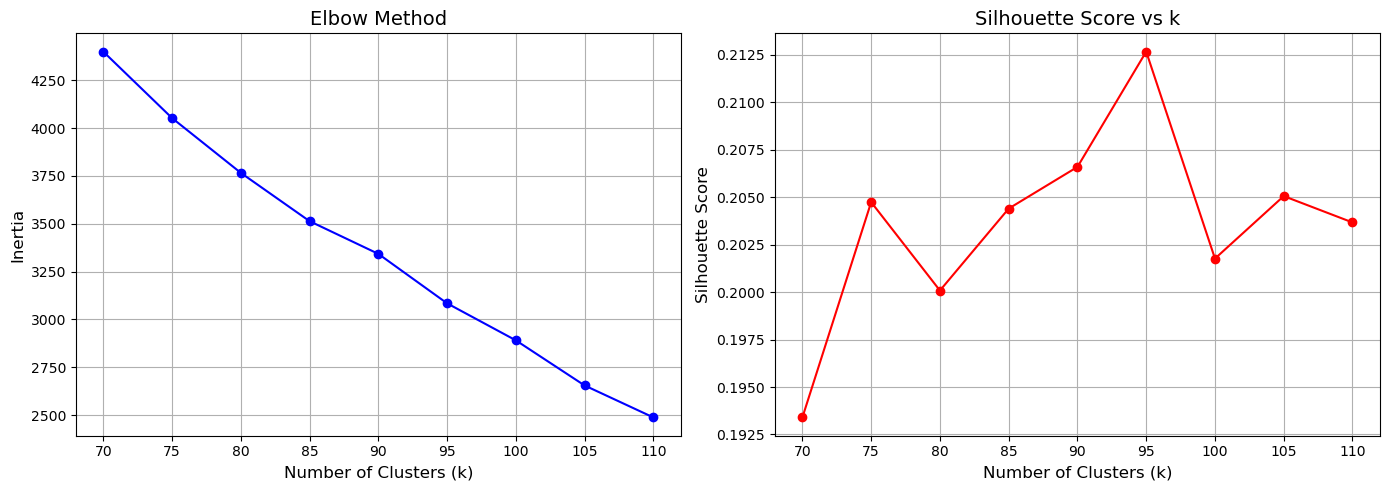


Best k based on silhouette score: 95 (silhouette=0.213)


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Test different numbers of clusters
k_values = list(range(70, 111, 5))  # Test from 70 to 110 clusters
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_train_faces)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_faces, km.labels_))
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={sil_scores[-1]:.3f}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(k_values, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14)
ax1.grid(True)

# Silhouette plot
ax2.plot(k_values, sil_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs k', fontsize=14)
ax2.grid(True)

plt.tight_layout()
plt.show()

# Find best k based on silhouette score
best_k = k_values[sil_scores.index(max(sil_scores))]
best_sil = max(sil_scores)
print(f"\nBest k based on silhouette score: {best_k} (silhouette={best_sil:.3f})")

I originally ran this for k in the range [20, 120] in increments of 10

The Elbow Method does not give any indication that there is an elbow point.

There are only 40 faces, I thought about chosing a range around 40 and retesting.

There is something of a peak on the Silhouette Scoure around 95 so I reran for k in the range [70, 110] in increments of 5.

### Apply k-means with the optimal k found above

In [24]:
# Train final k-means with optimal k
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
kmeans_final.fit(X_train_faces)

# Get cluster labels for training set
train_labels = kmeans_final.labels_

print(f"Final model trained with k={best_k}")
print(f"Number of images per cluster:")
unique, counts = np.unique(train_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} images")

Final model trained with k=95
Number of images per cluster:
  Cluster 0: 2 images
  Cluster 1: 3 images
  Cluster 2: 4 images
  Cluster 3: 6 images
  Cluster 4: 3 images
  Cluster 5: 4 images
  Cluster 6: 6 images
  Cluster 7: 4 images
  Cluster 8: 2 images
  Cluster 9: 3 images
  Cluster 10: 4 images
  Cluster 11: 2 images
  Cluster 12: 5 images
  Cluster 13: 6 images
  Cluster 14: 3 images
  Cluster 15: 2 images
  Cluster 16: 7 images
  Cluster 17: 3 images
  Cluster 18: 3 images
  Cluster 19: 2 images
  Cluster 20: 3 images
  Cluster 21: 3 images
  Cluster 22: 3 images
  Cluster 23: 3 images
  Cluster 24: 4 images
  Cluster 25: 3 images
  Cluster 26: 2 images
  Cluster 27: 2 images
  Cluster 28: 3 images
  Cluster 29: 2 images
  Cluster 30: 1 images
  Cluster 31: 2 images
  Cluster 32: 2 images
  Cluster 33: 5 images
  Cluster 34: 2 images
  Cluster 35: 6 images
  Cluster 36: 3 images
  Cluster 37: 2 images
  Cluster 38: 2 images
  Cluster 39: 1 images
  Cluster 40: 2 images
  Clust

### Visualize clusters: show sample faces from selected clusters
Let's examine several clusters to see if similar faces are grouped together.

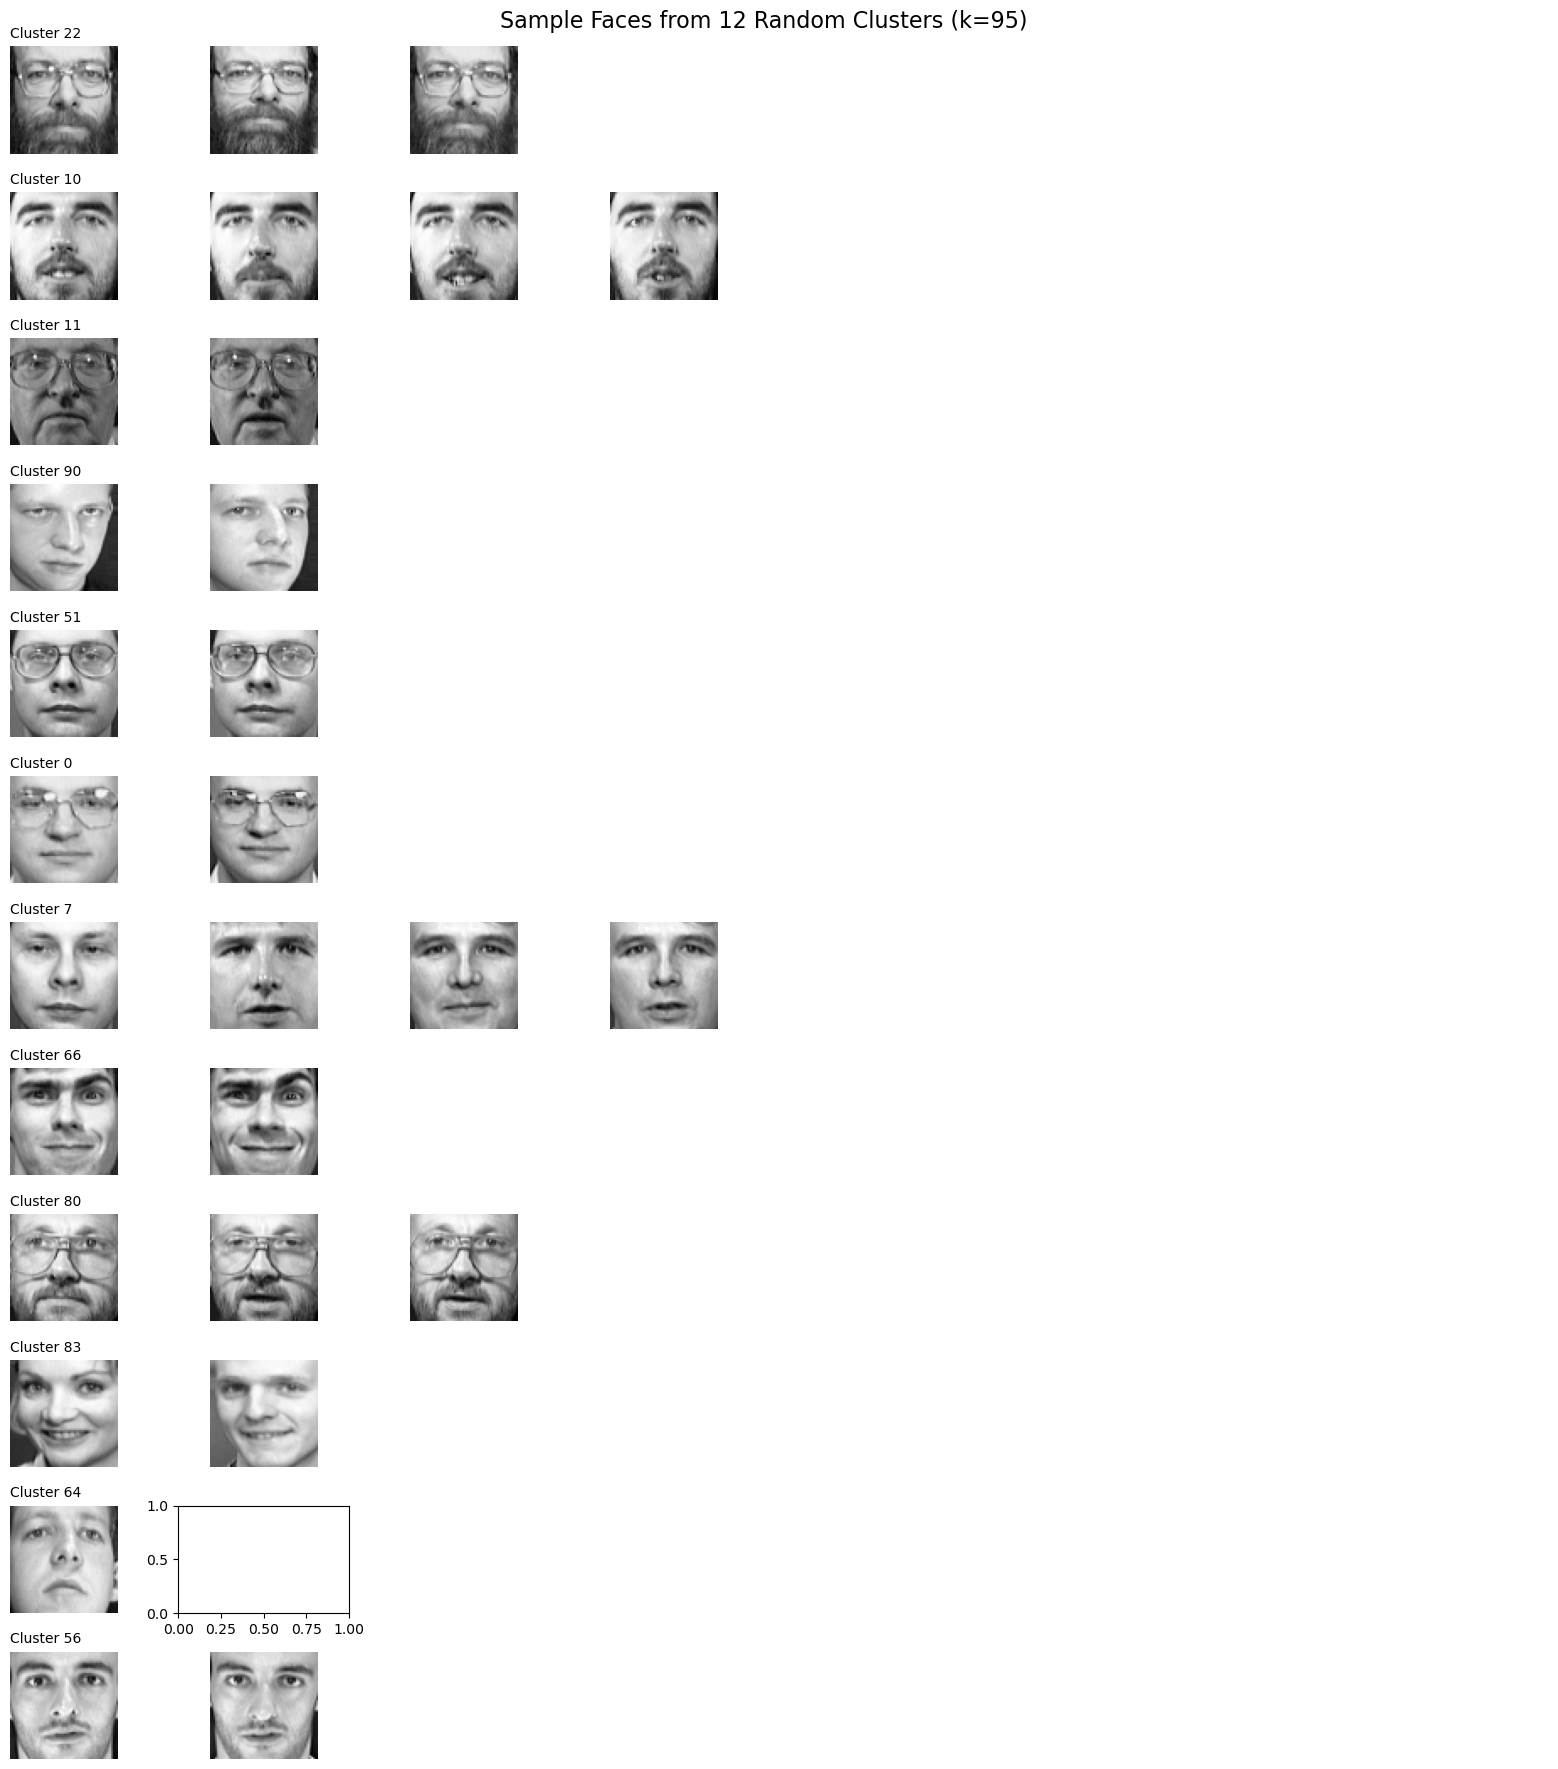

In [23]:
# Reshape training data back to images for visualization
X_train_images = X_train_faces.reshape(-1, 64, 64)

# Select clusters to visualize (pick 6 different clusters)
clusters_to_show = np.random.choice(best_k, size=12, replace=False)
n_images_per_cluster = 8  # Show 8 faces per cluster

fig, axes = plt.subplots(12, n_images_per_cluster, figsize=(16, 18))
fig.suptitle(f'Sample Faces from 12 Random Clusters (k={best_k})', fontsize=16)

for row, cluster_id in enumerate(clusters_to_show):
    # Get indices of images in this cluster
    cluster_indices = np.where(train_labels == cluster_id)[0]
    
    # Randomly sample n_images_per_cluster from this cluster
    sample_indices = np.random.choice(cluster_indices, 
                                     size=min(n_images_per_cluster, len(cluster_indices)), 
                                     replace=False)
    
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(X_train_images[idx], cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'Cluster {cluster_id}', fontsize=10, loc='left')

# Hide any unused subplots
for row in range(12):
    for col in range(n_images_per_cluster):
        if col >= len(sample_indices):
            axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Find cluster with most unique people (highest diversity)

Cluster 16 has the most diversity with 4 unique people
Total images in cluster: 7


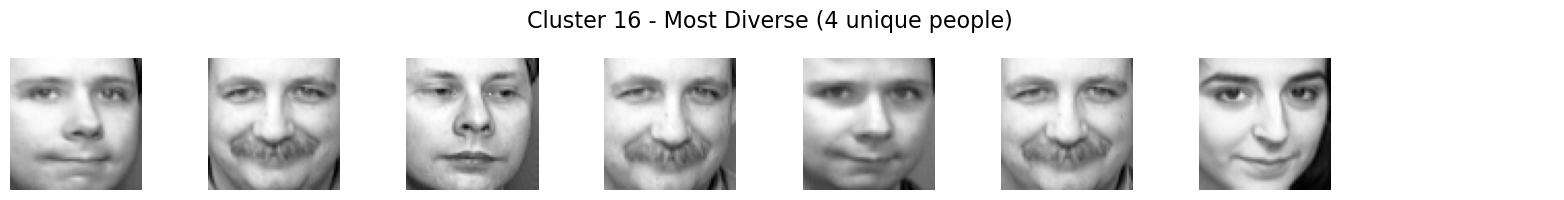

In [27]:
# Find the cluster with the most unique person IDs
max_unique_people = 0
most_diverse_cluster = 0

for cluster_id in range(best_k):
    cluster_indices = np.where(train_labels == cluster_id)[0]
    person_ids_in_cluster = y_train_faces[cluster_indices]
    unique_people = len(np.unique(person_ids_in_cluster))
    
    if unique_people > max_unique_people:
        max_unique_people = unique_people
        most_diverse_cluster = cluster_id

print(f"Cluster {most_diverse_cluster} has the most diversity with {max_unique_people} unique people")

# Display images from this cluster
fig, axes = plt.subplots(1, n_images_per_cluster, figsize=(16, 2))
fig.suptitle(f'Cluster {most_diverse_cluster} - Most Diverse ({max_unique_people} unique people)', fontsize=16)

# Get indices of images in this cluster
cluster_indices = np.where(train_labels == most_diverse_cluster)[0]
print(f"Total images in cluster: {len(cluster_indices)}")

# Randomly sample n_images_per_cluster from this cluster
sample_indices = np.random.choice(cluster_indices, 
                                 size=min(n_images_per_cluster, len(cluster_indices)), 
                                 replace=False)

# Display images
for col, idx in enumerate(sample_indices):
    axes[col].imshow(X_train_images[idx], cmap='gray')
    axes[col].axis('off')

# Hide any unused subplots
for col in range(len(sample_indices), n_images_per_cluster):
    axes[col].axis('off')

plt.tight_layout()
plt.show()

## I think it is matching cluster 16 on eyes. The woman's mouth is simolar to the guy without the mustache.

### Visualize cluster centers
Show the "average face" for each cluster by displaying the cluster centroids.

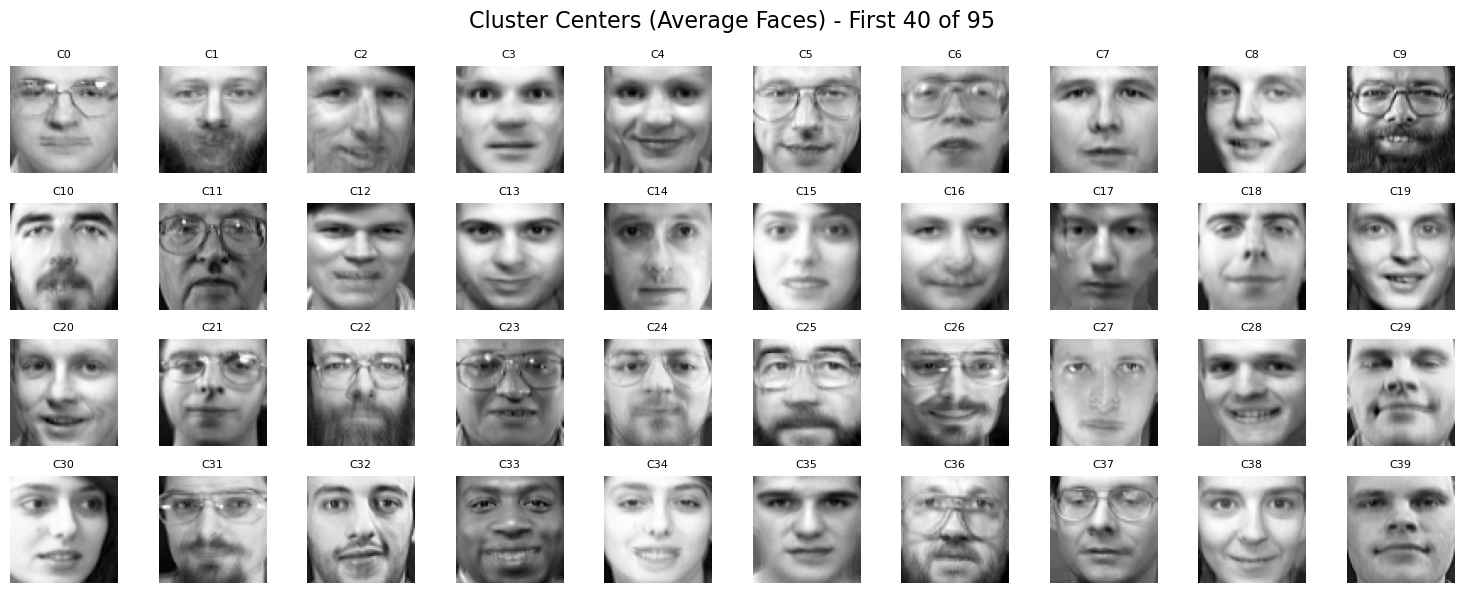

In [18]:
# Get cluster centers and reshape to images
cluster_centers = kmeans_final.cluster_centers_.reshape(-1, 64, 64)

# Display first 40 cluster centers (or all if less than 40)
n_centers_to_show = min(40, best_k)
n_cols = 10
n_rows = (n_centers_to_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 1.5))
fig.suptitle(f'Cluster Centers (Average Faces) - First {n_centers_to_show} of {best_k}', fontsize=16)

for i in range(n_centers_to_show):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col] if n_rows > 1 else axes[col]
    ax.imshow(cluster_centers[i], cmap='gray')
    ax.set_title(f'C{i}', fontsize=8)
    ax.axis('off')

# Hide unused subplots
for i in range(n_centers_to_show, n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col] if n_rows > 1 else axes[col]
    ax.axis('off')

plt.tight_layout()
plt.show()

### Analyze: Which people (person IDs) are grouped in each cluster?
Check if clusters tend to group images of the same person together.

In [19]:
# Analyze cluster composition - show which person IDs are in each cluster
print("Cluster composition analysis (showing 10 example clusters):\n")

# Select 10 random clusters to examine
sample_clusters = np.random.choice(best_k, size=min(10, best_k), replace=False)

for cluster_id in sorted(sample_clusters):
    cluster_indices = np.where(train_labels == cluster_id)[0]
    person_ids_in_cluster = y_train_faces[cluster_indices]
    
    # Count how many images of each person are in this cluster
    unique_persons, counts = np.unique(person_ids_in_cluster, return_counts=True)
    
    print(f"Cluster {cluster_id} ({len(cluster_indices)} images):")
    print(f"  Contains images of {len(unique_persons)} different people")
    
    # Show top 5 most common people in this cluster
    top_indices = np.argsort(counts)[::-1][:5]
    top_persons = unique_persons[top_indices]
    top_counts = counts[top_indices]
    
    print(f"  Most common: ", end="")
    for person, count in zip(top_persons, top_counts):
        print(f"Person {person}({count}) ", end="")
    print("\n")

Cluster composition analysis (showing 10 example clusters):

Cluster 3 (6 images):
  Contains images of 1 different people
  Most common: Person 17(6) 

Cluster 8 (2 images):
  Contains images of 1 different people
  Most common: Person 39(2) 

Cluster 9 (3 images):
  Contains images of 1 different people
  Most common: Person 36(3) 

Cluster 12 (5 images):
  Contains images of 1 different people
  Most common: Person 32(5) 

Cluster 28 (3 images):
  Contains images of 1 different people
  Most common: Person 4(3) 

Cluster 58 (4 images):
  Contains images of 1 different people
  Most common: Person 37(4) 

Cluster 61 (1 images):
  Contains images of 1 different people
  Most common: Person 35(1) 

Cluster 62 (1 images):
  Contains images of 1 different people
  Most common: Person 15(1) 

Cluster 90 (2 images):
  Contains images of 1 different people
  Most common: Person 0(2) 

Cluster 94 (2 images):
  Contains images of 1 different people
  Most common: Person 31(2) 

